# 🤖 DecodeLabs AI Internship - Project 3

## AI Recommendation Logic

### 👤 Name: Vishwas Parashar
### 🎓 College: GLA University, Mathura
### 💻 Project: AI Recommendation System
### 📊 Technique: Content-Based Recommendation
### 🛠 Platform: Google Colab

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Create Dataset

data = {
    "Role": [
        "Data Scientist",
        "Machine Learning Engineer",
        "Web Developer",
        "Android Developer",
        "Cloud Engineer",
        "Cyber Security Analyst",
        "Game Developer",
        "AI Engineer"
    ],

    "Skills": [
        "Python Machine Learning SQL Data Analysis",
        "Python TensorFlow Deep Learning AI",
        "HTML CSS JavaScript React",
        "Java Kotlin Android Firebase",
        "AWS Docker Kubernetes Linux",
        "Networking Linux Python Security",
        "Unity C# Game Development Blender",
        "Python Machine Learning TensorFlow NLP"
    ]
}

df = pd.DataFrame(data)

df

,Role,Skills
0,Data Scientist,Python Machine Learning SQL Data Analysis
1,Machine Learning Engineer,Python TensorFlow Deep Learning AI
2,Web Developer,HTML CSS JavaScript React
3,Android Developer,Java Kotlin Android Firebase
4,Cloud Engineer,AWS Docker Kubernetes Linux
5,Cyber Security Analyst,Networking Linux Python Security
6,Game Developer,Unity C# Game Development Blender
7,AI Engineer,Python Machine Learning TensorFlow NLP


In [3]:
# Convert Skills into TF-IDF Matrix

vectorizer = TfidfVectorizer()

skill_matrix = vectorizer.fit_transform(df["Skills"])

print("TF-IDF Matrix Shape:", skill_matrix.shape)

TF-IDF Matrix Shape: (8, 28)


In [5]:
# User Skills

user_skills = input("Enter your skills (comma separated): ")

Enter your skills (comma separated): Python, Machine Learning, SQL


In [6]:
# Convert User Skills

user_vector = vectorizer.transform([user_skills])

In [7]:
# Calculate Similarity

similarity = cosine_similarity(user_vector, skill_matrix)

print(similarity)

[[0.75352215 0.29964425 0.         0.         0.         0.14077684
  0.         0.55021014]]


In [8]:
# Top Recommendations

scores = similarity.flatten()

df["Similarity Score"] = scores

recommendations = df.sort_values(
    by="Similarity Score",
    ascending=False
)

recommendations

,Role,Skills,Similarity Score
0,Data Scientist,Python Machine Learning SQL Data Analysis,0.753522
7,AI Engineer,Python Machine Learning TensorFlow NLP,0.550210
1,Machine Learning Engineer,Python TensorFlow Deep Learning AI,0.299644
5,Cyber Security Analyst,Networking Linux Python Security,0.140777
3,Android Developer,Java Kotlin Android Firebase,0.000000
2,Web Developer,HTML CSS JavaScript React,0.000000
4,Cloud Engineer,AWS Docker Kubernetes Linux,0.000000
6,Game Developer,Unity C# Game Development Blender,0.000000


In [9]:
# Top 3 Recommended Roles

top3 = recommendations.head(3)

print("Top 3 Recommended Career Paths\n")

print(top3[["Role","Similarity Score"]])

Top 3 Recommended Career Paths

                        Role  Similarity Score
0             Data Scientist          0.753522
7                AI Engineer          0.550210
1  Machine Learning Engineer          0.299644


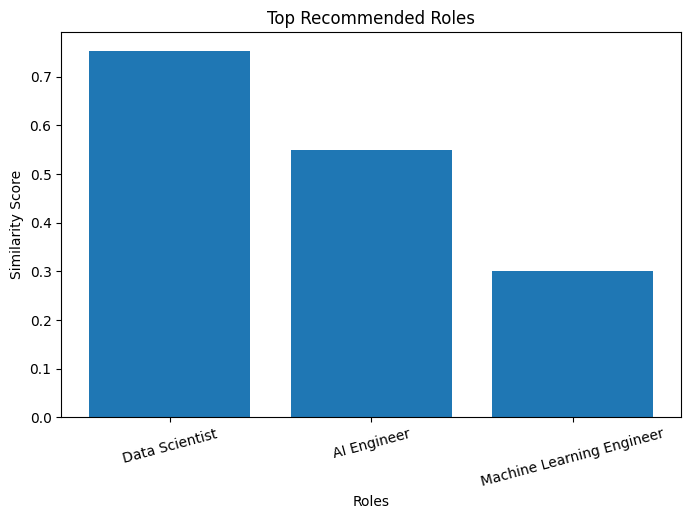

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    top3["Role"],
    top3["Similarity Score"]
)

plt.title("Top Recommended Roles")
plt.xlabel("Roles")
plt.ylabel("Similarity Score")

plt.xticks(rotation=15)

plt.show()